# MidiSeq2PrefixInTokenLevel — SPLIT-MODALITY model validation

Loads the `Seq2CondSplitMidiPatchy` dataset and the `MidiSeq2PrefixInTokenLevel` /
`MidiSeq2PrefixInTokenLevelLoss` model — the **split-modality** midiseq2 variant that moves the
lilylet conditioning into the **token-level** decoder.

Unlike `MidiSeq2BgptSelfAttn` (one joint `[T,64]` tensor, lilylet ids left-aligned into the midi
frame, a frozen encoder scattered into the joint sequence), this pipeline keeps the two modalities
**separate**:

- `lyl_patches [B,Lmax,16]` (lilylet vocab 256) and `midi_patches [B,Mmax,64]` (midiseq2 vocab 838)
  — no widening, no shared integer axis, no clamp.
- The decoder runs **midi-only** self-attention under `midi_attn_mask` (the midi block of
  `build_vis`); there is **no lyl encoder**.
- For each supervised midi target patch, the lyl patches in its **cross window** — derived directly
  from measure ids (`midi_src` / `lyl_meas` / `w_cross`), **not a mask tensor** — are re-embedded raw
  and **prepended** in a `PrefixTokenLevelDecoder` at **negative, increasing** positions (`-Kmax..-1`).

This notebook: inspects a split batch, builds the model, verifies **(i)** it is a plain `nn.Module`
with no encoder, **(ii)** the midi-only mask gates the decoder, **(iii)** the measure-id cross gather
equals the `build_vis` cross selection, **(iv)** the token decoder's negative prefix positions and
`Kmax==0` parity with the stock `TokenLevelDecoder`, **(v)** the per-token-type metrics + nan-safe
`stat()`, runs a forward pass, and overfits one batch.

Config: `configs/midi-measurewise-seq2split-prefixtl.yaml` ·
Data: `~/data/lilylet/midi-measurewise/test20260629/cond-midiseq2-split.lmmw.pt`
(build it with `tools/midi/buildCondMidiseq2MeasurewiseSplit.py --dataset <test20260629>/dataset.yaml`).

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
import torch.nn.functional as F
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

DATA_DIR = str(Path.home() / 'data')
CONFIG = str(REPO_ROOT / 'configs' / 'midi-measurewise-seq2split-prefixtl.yaml')
print('repo:', REPO_ROOT)
print('data dir:', DATA_DIR)

repo: /home/camus/work/deep-starry
data dir: /home/camus/data


In [2]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

INK = '#202124'
MUTED = '#667085'
GRID = '#D0D5DD'
NEUTRAL = '#F2F4F7'
ACCENT = '#2563EB'
HISTORICAL = '#C2410C'
CORRECTED = '#047857'
BINARY_CMAP = ListedColormap([NEUTRAL, ACCENT])


def show_binary_mask(ax, mask, title, xlabels=None, ylabels=None, annotate=False):
    """Plot a bool matrix with rows=query and columns=key."""
    data = mask.detach().cpu().bool().numpy()
    ax.imshow(data, cmap=BINARY_CMAP, vmin=0, vmax=1, interpolation='nearest', aspect='auto')
    ax.set_title(title, color=INK)
    ax.set_xlabel('key position')
    ax.set_ylabel('query position')
    if xlabels is not None:
        ax.set_xticks(range(len(xlabels)), xlabels, rotation=90 if len(xlabels) > 12 else 0)
    if ylabels is not None:
        ax.set_yticks(range(len(ylabels)), ylabels)
    if annotate and data.shape[0] <= 12 and data.shape[1] <= 12:
        for q in range(data.shape[0]):
            for k in range(data.shape[1]):
                ax.text(k, q, str(int(data[q, k])), ha='center', va='center',
                        color='white' if data[q, k] else INK, fontsize=8)
    return ax


def metric_table(ax, columns, rows, title=None):
    """Render a compact companion table so values are not encoded by color alone."""
    ax.axis('off')
    if title:
        ax.set_title(title, loc='left', color=INK, pad=8)
    table = ax.table(cellText=rows, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.25)
    return table

print('visualization helpers ready')

visualization helpers ready


## 1. Load dataset + a small CPU model, inspect one split batch

The corpus is NOT cropped (`max_patches: 0`), so we shrink the model (not the data) to keep this
validation quick on CPU. A 2-sample batch of differing length exercises padding. Note the two
independent patch widths on the batch: `lyl_patches` at 16, `midi_patches` at 64.

In [3]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
config['data.batch_size'] = 2
config['trainer.device'] = 'cpu'
# smaller model keeps this validation quick on CPU (data stays uncropped).
config['model.args.d_model'] = 96
config['model.args.n_dec_layer'] = 2
config['model.args.token_num_layers'] = 2
config['model.args.n_head'] = 4
config['model.args.dec_num_key_value_heads'] = 4
config['model.args.num_key_value_heads'] = 4
config['model.args.d_inner'] = 192

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
for k in ['lyl_patches', 'lyl_masks', 'lyl_meas', 'midi_patches', 'midi_masks', 'midi_meas',
          'midi_src', 'midi_targets', 'midi_positions', 'midi_attn_mask']:
    print(f'  {k:16} {tuple(batch[k].shape)} {batch[k].dtype}')
print('lyl patch width  :', batch['lyl_patches'].shape[-1], '(lyl_patch_size=16)')
print('midi patch width :', batch['midi_patches'].shape[-1], '(midiseq2 patch_size=64)')
print('max lyl id       :', int(batch['lyl_patches'].max()), '(< lyl vocab 256)')
print('max midi id      :', int(batch['midi_patches'].max()), '(midiseq2 vocab up to 837)')
print('real lyl / midi  :', batch['lyl_masks'].sum(1).tolist(), '/', batch['midi_masks'].sum(1).tolist())
print('midi targets     :', batch['midi_targets'].sum(1).tolist())
# split layout keeps the two vocabularies disjoint: lyl ids never reach the midi range.
assert int(batch['lyl_patches'].max()) < 256

train items: 205 val items: 10
batch keys: ['lyl_patches', 'lyl_masks', 'lyl_meas', 'midi_patches', 'midi_masks', 'midi_meas', 'midi_src', 'midi_targets', 'midi_positions', 'midi_attn_mask', 'lyl_patch_size', 'midi_patch_size']
  lyl_patches      (2, 521, 16) torch.int64
  lyl_masks        (2, 521) torch.int64
  lyl_meas         (2, 521) torch.int64
  midi_patches     (2, 190, 64) torch.int64
  midi_masks       (2, 190) torch.int64
  midi_meas        (2, 190) torch.int64
  midi_src         (2, 190) torch.int64
  midi_targets     (2, 190) torch.int64
  midi_positions   (2, 190) torch.int64
  midi_attn_mask   (2, 1, 190, 190) torch.bool
lyl patch width  : 16 (lyl_patch_size=16)
midi patch width : 64 (midiseq2 patch_size=64)
max lyl id       : 248 (< lyl vocab 256)
max midi id      : 836 (midiseq2 vocab up to 837)
real lyl / midi  : [344, 521] / [136, 190]
midi targets     : [135, 189]


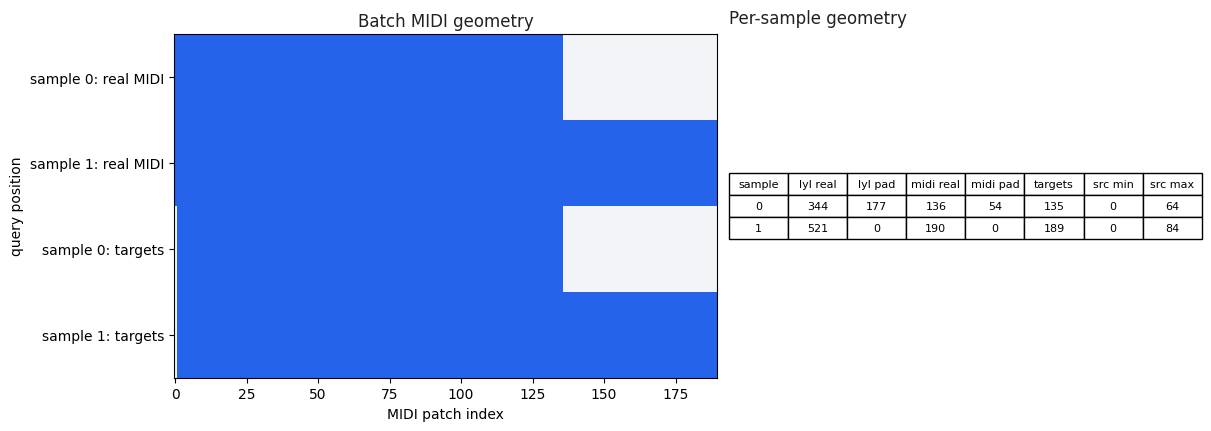

In [4]:
# Batch geometry: real/padded regions and next-patch targets.
B, Lmax = batch['lyl_masks'].shape
Mmax = batch['midi_masks'].shape[1]
geometry_rows = []
for bb in range(B):
    lr = int(batch['lyl_masks'][bb].sum())
    mr = int(batch['midi_masks'][bb].sum())
    nt = int(batch['midi_targets'][bb].sum())
    real_src = batch['midi_src'][bb, :mr]
    geometry_rows.append([bb, lr, Lmax - lr, mr, Mmax - mr, nt,
                          int(real_src.min()), int(real_src.max())])

fig = plt.figure(figsize=(12, 4.2), layout='constrained')
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1])
ax = fig.add_subplot(gs[0, 0])
raster = torch.cat((batch['midi_masks'], batch['midi_targets']), dim=0)
labels = [f'sample {bb}: real MIDI' for bb in range(B)] + [f'sample {bb}: targets' for bb in range(B)]
show_binary_mask(ax, raster, 'Batch MIDI geometry', ylabels=labels)
ax.set_xlabel('MIDI patch index')
metric_table(fig.add_subplot(gs[0, 1]),
             ['sample', 'lyl real', 'lyl pad', 'midi real', 'midi pad', 'targets', 'src min', 'src max'],
             geometry_rows, 'Per-sample geometry')
plt.show()

assert all((batch['midi_targets'][bb] <= batch['midi_masks'][bb]).all() for bb in range(B))
assert any(row[2] > 0 or row[4] > 0 for row in geometry_rows), 'batch should exercise padding'

## 2. Build the model via the factory — a plain `nn.Module`, no encoder

`MidiSeq2PrefixInTokenLevel` is a plain `nn.Module` (it does **not** subclass `MidiSeq2BgptSelfAttn`):
it builds only what it uses — `midi_embedding`, a midi self-attention `decoder` (`LlamaModel`), a
`PrefixTokenLevelDecoder` token head, and the raw-lyl `lyl_prefix_embedding`. There is no
`lyl_encoder` / `enc_proj`.

In [5]:
deducer = loadModel(config['model'], imports=config['imports'])
model = loadModel(config['model'], postfix='Loss', imports=config['imports'])
print('deducer:', type(deducer).__name__, '| loss model:', type(model).__name__)
print('deducer MRO:', [c.__name__ for c in type(deducer).__mro__[:3]])

d = model.deducer
print('child modules:', [n for n, _ in d.named_children()])
print('has lyl_encoder:', hasattr(d, 'lyl_encoder'), '| has enc_proj:', hasattr(d, 'enc_proj'))
n_params = sum(p.numel() for p in d.parameters())
print('params: %.2fM' % (n_params / 2**20))
print('midi_embedding in_features   :', d.midi_embedding.in_features, '(64*838=53632)')
print('lyl_prefix_embedding in_feat :', d.lyl_prefix_embedding.in_features, '(16*256=4096)')
print('decoder layers:', d.decoder.config.num_hidden_layers,
      '| token head:', type(d.token_level_decoder).__name__,
      'layers', d.token_level_decoder.base.config.num_hidden_layers,
      'vocab', d.token_level_decoder.base.config.vocab_size)
print('w_cross:', d.w_cross, '| patch_size:', d.patch_size, '| lyl_patch_size:', d.lyl_patch_size)
assert not hasattr(d, 'lyl_encoder') and not hasattr(d, 'enc_proj')
assert d.token_level_decoder.base.config.vocab_size == 838

deducer: MidiSeq2PrefixInTokenLevel | loss model: MidiSeq2PrefixInTokenLevelLoss
deducer MRO: ['MidiSeq2PrefixInTokenLevel', 'Module', 'object']
child modules: ['midi_embedding', 'lyl_prefix_embedding', 'decoder', 'token_level_decoder']
has lyl_encoder: False | has enc_proj: False
params: 5.79M
midi_embedding in_features   : 53632 (64*838=53632)
lyl_prefix_embedding in_feat : 4096 (16*256=4096)
decoder layers: 2 | token head: PrefixTokenLevelDecoder layers 2 vocab 838
w_cross: 1 | patch_size: 64 | lyl_patch_size: 16


## 3. Midi-only mask gates the decoder

Blocking a real midi query row in `midi_attn_mask` changes that row's decoder hidden state, while an
unaffected earlier row is bit-identical — the windowed midi->midi coupling is enforced by the fused
attention backbone. (There is no lyl in the decoder at all — the lilylet signal only enters later, at
the token level.)

In [6]:
m = model.deducer
m.eval()
midi_patches = batch['midi_patches'].reshape(len(batch['midi_patches']), -1, m.patch_size)
b = int(batch['midi_masks'].sum(1).argmax())        # densest midi sample
with torch.no_grad():
    embeds = m._midi_embed(midi_patches)
real_midi = (batch['midi_masks'][b] == 1).nonzero().flatten()
qrow = int(real_midi[-1]); row0 = int(real_midi[0])
full = batch['midi_attn_mask'].clone()
blocked = full.clone()
blocked[b, 0, qrow, :] = False
blocked[b, 0, qrow, qrow] = True
with torch.no_grad():
    h_full = m.decoder(inputs_embeds=embeds, attention_mask=full, position_ids=batch['midi_positions'])['last_hidden_state']
    h_blk = m.decoder(inputs_embeds=embeds, attention_mask=blocked, position_ids=batch['midi_positions'])['last_hidden_state']
print('blocked query row hidden changes  :', not torch.allclose(h_full[b, qrow], h_blk[b, qrow], atol=1e-6))
print('earlier row (unaffected) identical:', torch.allclose(h_full[b, row0], h_blk[b, row0], atol=1e-6))
assert not torch.allclose(h_full[b, qrow], h_blk[b, qrow], atol=1e-6)
assert torch.allclose(h_full[b, row0], h_blk[b, row0], atol=1e-6)

blocked query row hidden changes  : True
earlier row (unaffected) identical: True


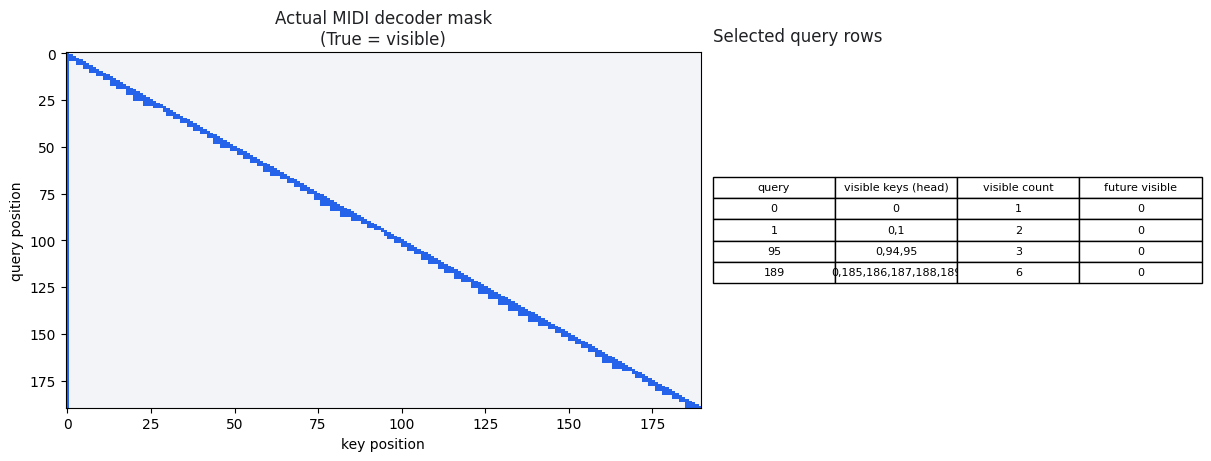

future-visible MIDI key pairs: 0


In [7]:
# Inspect the actual MIDI patch-level visibility matrix and prove its direction.
Mp = int(batch['midi_masks'][b].sum())
real_mask = batch['midi_attn_mask'][b, 0, :Mp, :Mp]
future = torch.triu(torch.ones(Mp, Mp, dtype=torch.bool), diagonal=1)  # key > query
future_visible = real_mask & future
row_ids = sorted(set([0, min(1, Mp - 1), Mp // 2, Mp - 1]))
row_summary = []
for q in row_ids:
    keys = torch.nonzero(real_mask[q], as_tuple=False).flatten().tolist()
    shown = ','.join(map(str, keys[:12])) + ('…' if len(keys) > 12 else '')
    row_summary.append([q, shown, len(keys), int(future_visible[q].sum())])

fig = plt.figure(figsize=(12, 4.5), layout='constrained')
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])
show_binary_mask(fig.add_subplot(gs[0, 0]), real_mask, 'Actual MIDI decoder mask\n(True = visible)')
metric_table(fig.add_subplot(gs[0, 1]), ['query', 'visible keys (head)', 'visible count', 'future visible'],
             row_summary, 'Selected query rows')
plt.show()

print('future-visible MIDI key pairs:', int(future_visible.sum()))
assert not future_visible.any(), 'midi_attn_mask exposes a future MIDI patch'

## 4. Measure-id cross gather == `build_vis` cross selection

The distinctive design point: instead of consuming a midi->lyl cross **mask**, the model computes,
per midi target patch, which lyl patches fall in its `w_cross` window directly from measure ids
(`_gather_lyl_prefix`). This must select exactly the same lyl set as the reference `build_vis` cross
block. We verify equality for `w_cross` in `{1, 2, 4}` on every midi target of the batch.

In [8]:
from starry.midi.data.condPatchy import build_vis

def build_vis_cross_sets(batch, b, wc):
    '''Reference lyl selection per midi target, from build_vis on the reconstructed joint sequence.'''
    Lp = int(batch['lyl_masks'][b].sum()); Mp = int(batch['midi_masks'][b].sum())
    mod = torch.cat((torch.zeros(Lp, dtype=torch.long), torch.ones(Mp, dtype=torch.long)))
    own = torch.cat((batch['lyl_meas'][b, :Lp], batch['midi_meas'][b, :Mp]))
    src = torch.cat((batch['lyl_meas'][b, :Lp], batch['midi_src'][b, :Mp]))
    vis = build_vis(mod, own, src, 4, wc)                       # w_midi irrelevant to the cross block
    return {q: set(torch.nonzero((vis[Lp + q, :Lp]) & (mod[:Lp] == 0)).flatten().tolist()) for q in range(Mp)}

def model_cross_sets(batch, b, wc):
    '''The model's measure-id rule (mirrors _gather_lyl_prefix).'''
    Lp = int(batch['lyl_masks'][b].sum()); Mp = int(batch['midi_masks'][b].sum())
    lyl_meas = batch['lyl_meas'][b, :Lp]; midi_src = batch['midi_src'][b, :Mp]
    out = {}
    for p in range(Mp):
        s = int(midi_src[p])
        header = lyl_meas == 0
        inwin = (s != 0) & (lyl_meas > s - wc) & (lyl_meas <= s)
        out[p] = set(torch.nonzero(header | inwin).flatten().tolist())
    return out

for wc in (1, 2, 4):
    for bb in range(batch['midi_masks'].shape[0]):
        ref = build_vis_cross_sets(batch, bb, wc)
        got = model_cross_sets(batch, bb, wc)
        assert ref == got, (bb, wc, 'cross-set mismatch')
print('measure-id cross gather == build_vis cross selection for w_cross in {1,2,4}  OK')

measure-id cross gather == build_vis cross selection for w_cross in {1,2,4}  OK


## 5. Token decoder: negative prefix positions + `Kmax==0` parity

The `PrefixTokenLevelDecoder` prepends `Kmax` lyl prefixes at positions `-Kmax..-1`, the encoded
patch at `0`, and the `P` teacher-forced tokens at `1..P`; the prefix slots are excluded from the
returned logits (so downstream sees `[N, P+1, vocab]`). With `Kmax==0` it reduces **exactly** to the
stock `TokenLevelDecoder`.

In [9]:
from starry.bgpt.decoders import TokenLevelDecoder

# (a) run the real gather and confirm negative-increasing positions + prefix coverage
m.eval()
mp = batch['midi_patches'].reshape(len(batch['midi_patches']), -1, m.patch_size)
tgt_idx = torch.nonzero(batch['midi_targets'] == 1, as_tuple=False)
pe, pm = m._gather_lyl_prefix(batch['lyl_patches'], batch['lyl_masks'], batch['lyl_meas'],
                             batch['midi_src'], tgt_idx)
Kmax = pe.shape[1]
P1 = m.patch_size + 1
pos = torch.cat((torch.arange(-Kmax, 0), torch.arange(0, P1))).tolist()
print('Kmax:', Kmax, '| positions head/tail:', pos[:3], '...', pos[-3:])
print('prefix_mask rowsums: min', int(pm.sum(1).min()), 'max', int(pm.sum(1).max()), '(>=1 per body target)')
assert pos[:Kmax] == list(range(-Kmax, 0)) and pos[Kmax] == 0
assert int(pm.sum(1).min()) >= 1

# (b) Kmax==0 parity: PrefixTokenLevelDecoder with no prefix == stock TokenLevelDecoder
ptl = m.token_level_decoder
N, P, dm = 3, m.patch_size, m.d_model
enc = torch.randn(N, dm); tgt = torch.randint(1, m.midi_vocab_size, (N, P))
with torch.no_grad():
    out_no_prefix = ptl(enc, tgt, None, None)
    out_stock = super(type(ptl), ptl).forward(enc, tgt)     # grandparent TokenLevelDecoder.forward
dloss = abs(float(out_no_prefix.loss) - float(out_stock.loss))
print('Kmax==0 loss diff vs stock TokenLevelDecoder:', dloss)
assert dloss < 1e-5 and out_no_prefix.logits.shape == out_stock.logits.shape

Kmax: 12 | positions head/tail: [-12, -11, -10] ... [62, 63, 64]
prefix_mask rowsums: min 7 max 12 (>=1 per body target)
Kmax==0 loss diff vs stock TokenLevelDecoder: 0.0


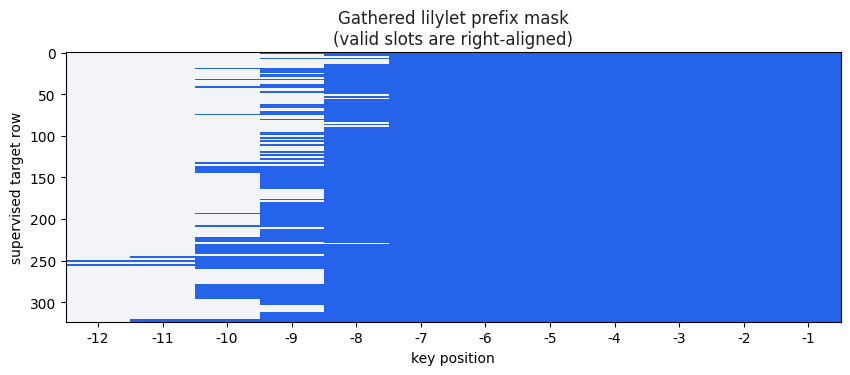

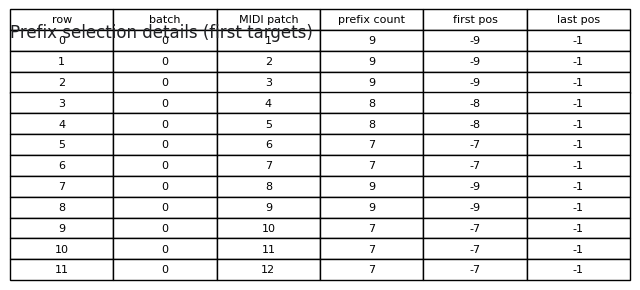

In [10]:
# Prefix right-alignment is visible as a target-by-slot raster.
valid_prefix = pm.bool()
slot_labels = list(range(-Kmax, 0))
fig, ax = plt.subplots(figsize=(10, 3.5))
show_binary_mask(ax, valid_prefix, 'Gathered lilylet prefix mask\n(valid slots are right-aligned)',
                 xlabels=slot_labels)
ax.set_ylabel('supervised target row')
plt.show()

prefix_rows = []
for rr in range(min(12, len(tgt_idx))):
    valid_slots = torch.nonzero(valid_prefix[rr], as_tuple=False).flatten().tolist()
    prefix_rows.append([rr, int(tgt_idx[rr, 0]), int(tgt_idx[rr, 1]),
                        len(valid_slots), valid_slots[0] - Kmax if valid_slots else 'none',
                        valid_slots[-1] - Kmax if valid_slots else 'none'])
fig, ax = plt.subplots(figsize=(8, 2.5))
metric_table(ax, ['row', 'batch', 'MIDI patch', 'prefix count', 'first pos', 'last pos'],
             prefix_rows, 'Prefix selection details (first targets)')
plt.show()
assert all(torch.all(valid_prefix[rr, :-int(valid_prefix[rr].sum())] == 0)
           if int(valid_prefix[rr].sum()) < Kmax else True for rr in range(len(valid_prefix)))

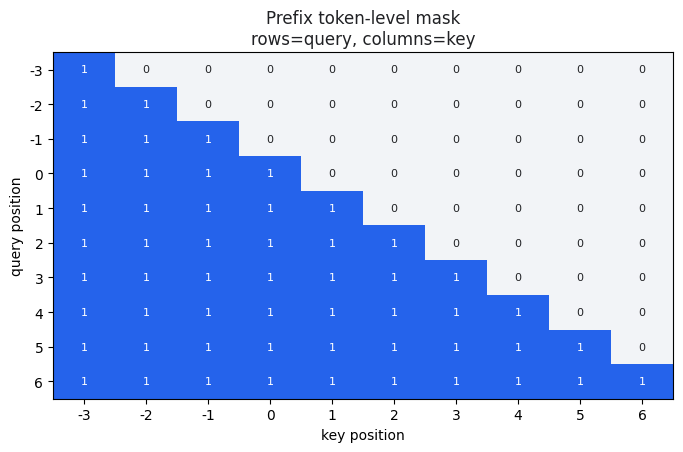

In [11]:
# Visualize a short prefix-token attention mask with negative RoPE positions.
K_demo, P_demo = min(3, Kmax), 6
positions_demo = list(range(-K_demo, 0)) + list(range(P_demo + 1))
idx_demo = torch.arange(len(positions_demo))
mask_demo = idx_demo.unsqueeze(0) <= idx_demo.unsqueeze(1)
fig, ax = plt.subplots(figsize=(8, 4.5))
show_binary_mask(ax, mask_demo, 'Prefix token-level mask\nrows=query, columns=key',
                 xlabels=positions_demo, ylabels=positions_demo, annotate=True)
plt.show()
assert not (mask_demo & torch.triu(torch.ones_like(mask_demo), diagonal=1)).any()
assert mask_demo.diag().all()

### 5a. Causal-mask orientation — historical leakage versus corrected geometry

Rows are **queries**, columns are **keys**. The historical comparison is intentionally reconstructed here: it permitted `key >= query`, so early queries could inspect future teacher-forced target tokens. The corrected mask permits only `key <= query`. These visualizations and assertions are regression guards for the exact transpose bug.

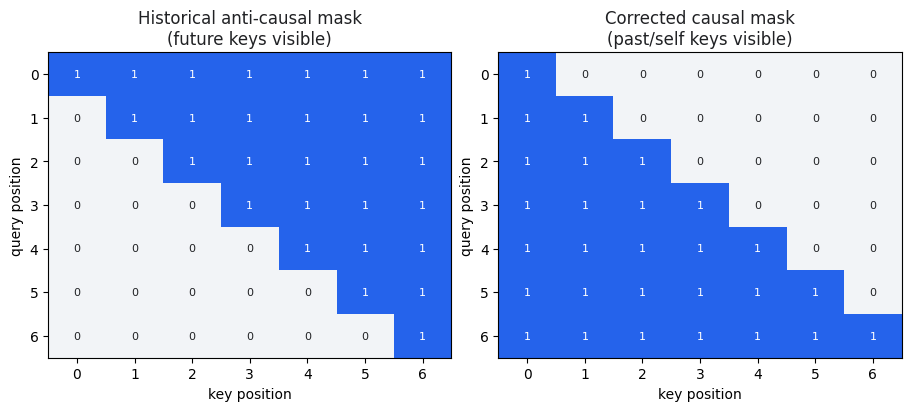

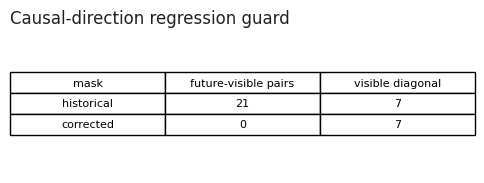

In [12]:
S_demo = 7
idx = torch.arange(S_demo)
historical_mask = idx.unsqueeze(0) >= idx.unsqueeze(1)  # [query,key] => key >= query
corrected_mask = idx.unsqueeze(0) <= idx.unsqueeze(1)   # [query,key] => key <= query
future_region = torch.triu(torch.ones(S_demo, S_demo, dtype=torch.bool), diagonal=1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout='constrained')
show_binary_mask(axes[0], historical_mask, 'Historical anti-causal mask\n(future keys visible)', annotate=True)
show_binary_mask(axes[1], corrected_mask, 'Corrected causal mask\n(past/self keys visible)', annotate=True)
plt.show()

orientation_rows = [
    ['historical', int((historical_mask & future_region).sum()),
     int((historical_mask & torch.eye(S_demo, dtype=torch.bool)).sum())],
    ['corrected', int((corrected_mask & future_region).sum()),
     int((corrected_mask & torch.eye(S_demo, dtype=torch.bool)).sum())],
]
fig, ax = plt.subplots(figsize=(6, 1.8))
metric_table(ax, ['mask', 'future-visible pairs', 'visible diagonal'], orientation_rows,
             'Causal-direction regression guard')
plt.show()

assert (historical_mask & future_region).any()
assert not (corrected_mask & future_region).any()
assert corrected_mask.diag().all()

## 6. Forward pass: loss, per-token-type metrics, inspectRun

The Loss reuses `MidiSeq2BgptSelfAttnLoss`'s machinery: base `acc`/`err` (always) plus, in **eval**
mode, the per-midiseq2-token-type ERROR rates (`err_type` / `err_elapse` / `err_pitch` / `err_vel` /
`err_channel` / `err_nibble`), each a nan-safe `WeightedValue(err, count)`. The token output exposes
prefix-sliced logits `[N, patch_size+1, vocab]`, so every helper works unchanged.

## 6a. Prefix labels and the BOS-shift diagnostic

In HF causal-LM loss, labels are shifted one position to the right. Therefore a historical
`[prefix=-100..., BOS, target...]` layout accidentally supervises the final prefix position
with BOS. The corrected prefix path masks the encoded context label at position 0.

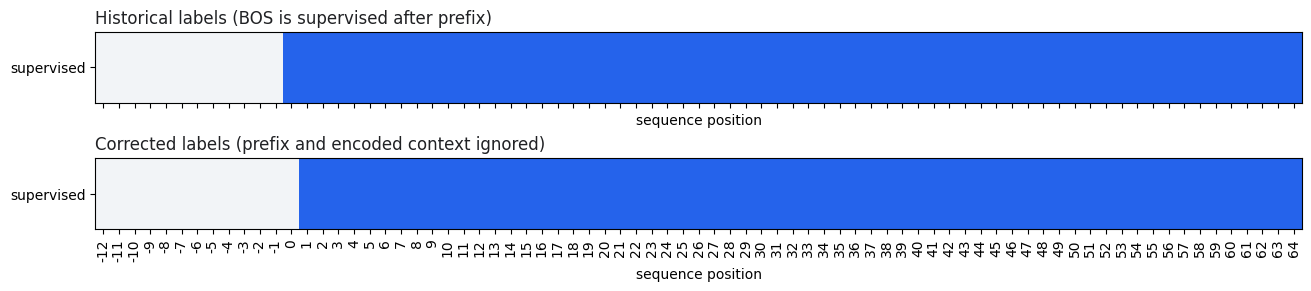

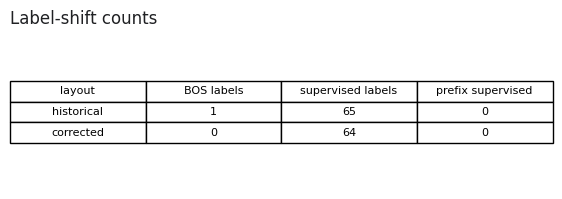

In [13]:
# Compare historical and corrected label layouts for one target patch.
label_target = batch['midi_patches'][int(tgt_idx[0, 0]), int(tgt_idx[0, 1])].reshape(1, -1)
bos = torch.full((1, 1), d.bos_token_id, dtype=label_target.dtype)
base_labels = torch.cat((bos, label_target), dim=1)
base_labels = base_labels.masked_fill(base_labels == d.special_token_id, -100)
K_label = int(pm.shape[1])
historical_labels = torch.cat((torch.full((1, K_label), -100, dtype=base_labels.dtype), base_labels), dim=1)
corrected_labels = historical_labels.clone()
corrected_labels[:, K_label] = -100

status = torch.zeros_like(historical_labels)
status[historical_labels == -100] = 0       # ignored
status[historical_labels == d.bos_token_id] = 1  # historical BOS supervision
status[(historical_labels > 2) & (historical_labels != d.special_token_id)] = 2  # target
status[corrected_labels == -100] = 0
status[corrected_labels[:, K_label] == -100, K_label] = 0
positions = list(range(-K_label, 0)) + list(range(base_labels.shape[1]))
fig, axes = plt.subplots(2, 1, figsize=(13, 2.8), sharex=True, layout='constrained')
for ax, vals, title in zip(axes, [historical_labels, corrected_labels],
                          ['Historical labels (BOS is supervised after prefix)',
                           'Corrected labels (prefix and encoded context ignored)']):
    ax.imshow((vals != -100).numpy(), cmap=ListedColormap([NEUTRAL, ACCENT]),
              vmin=0, vmax=1, aspect='auto')
    ax.set_title(title, loc='left', color=INK)
    ax.set_yticks([0], ['supervised'])
    ax.set_xticks(range(len(positions)), positions, rotation=90)
    ax.set_xlabel('sequence position')
plt.show()

label_rows = [
    ['historical', int((historical_labels == d.bos_token_id).sum()),
     int((historical_labels != -100).sum()), int((historical_labels[:, :K_label] != -100).sum())],
    ['corrected', int((corrected_labels == d.bos_token_id).sum()),
     int((corrected_labels != -100).sum()), int((corrected_labels[:, :K_label] != -100).sum())],
]
fig, ax = plt.subplots(figsize=(7, 2))
metric_table(ax, ['layout', 'BOS labels', 'supervised labels', 'prefix supervised'], label_rows,
             'Label-shift counts')
plt.show()
assert int((historical_labels[:, :K_label] != -100).sum()) == 0
assert int((corrected_labels[:, :K_label] != -100).sum()) == 0
assert int(corrected_labels[:, K_label].item()) == -100
assert int((historical_labels[:, K_label] == d.bos_token_id).sum()) == 1

## 6b. Isolated future-token leakage experiment

This experiment fixes the encoded patch and lilylet prefix, then changes only future teacher-forced token embeddings. Under a causal mask, logits for earlier positions must be invariant; under the historical anti-causal mask they should move. This isolates token-level leakage from patch-level context changes.

token decoder attention backend: eager


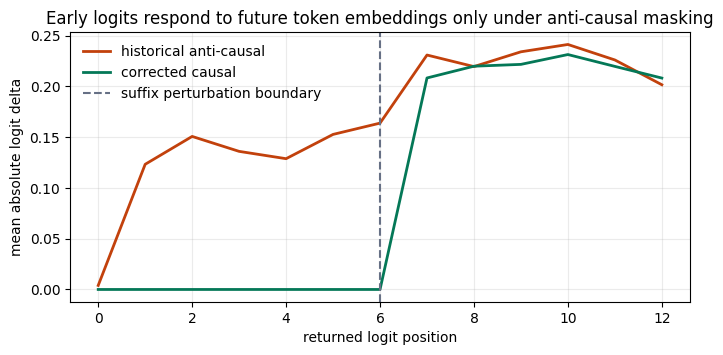

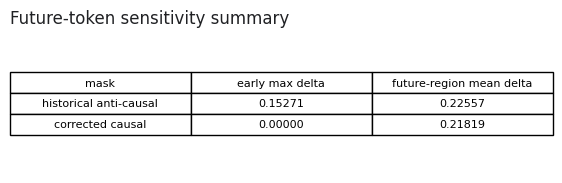

In [14]:
from starry.bgpt import token_embedding_weight

# Synthetic hidden/prefix inputs isolate token-level attention from patch-level context.
torch.manual_seed(7)
N_leak, P_leak, K_leak = 1, 12, min(4, Kmax)
hidden_leak = torch.randn(N_leak, d.d_model)
target_leak = torch.randint(3, d.midi_vocab_size, (N_leak, P_leak))
prefix_leak = torch.randn(N_leak, K_leak, d.d_model)
prefix_mask_leak = torch.ones(N_leak, K_leak, dtype=torch.long)
base = torch.cat((torch.full((N_leak, 1), d.bos_token_id, dtype=torch.long), target_leak), dim=1)
wte = token_embedding_weight(d.token_level_decoder.base)
base_emb = F.embedding(base, wte).to(hidden_leak.dtype)
base_emb[:, 0] = hidden_leak
perturbed_emb = base_emb.clone()
cut = 6
perturbed_emb[:, cut + 1:] = torch.randn_like(perturbed_emb[:, cut + 1:])


def decode_embeds_for_mask(token_embeds, historical):
    inputs = torch.cat((prefix_leak, token_embeds), dim=1)
    S = inputs.shape[1]
    ii = torch.arange(S)
    allowed = ii.unsqueeze(0) >= ii.unsqueeze(1) if historical else ii.unsqueeze(0) <= ii.unsqueeze(1)
    valid = torch.cat((prefix_mask_leak.bool(), torch.ones(N_leak, P_leak + 1, dtype=torch.bool)), dim=1)
    allowed = (allowed.unsqueeze(0) & valid.unsqueeze(1)) | torch.eye(S, dtype=torch.bool).unsqueeze(0)
    # Use an additive 4D mask so eager and SDPA backends share the same semantics.
    attn = torch.zeros_like(allowed, dtype=inputs.dtype).masked_fill(~allowed, torch.finfo(inputs.dtype).min)
    attn = attn.unsqueeze(1)
    pos = torch.cat((torch.arange(-K_leak, 0), torch.arange(P_leak + 1))).unsqueeze(0)
    with torch.no_grad():
        return d.token_level_decoder.base(inputs_embeds=inputs, attention_mask=attn,
                                          position_ids=pos).logits[:, K_leak:, :]

print('token decoder attention backend:', d.token_level_decoder.base.config._attn_implementation)
logit_deltas = {}
for name, historical in [('historical anti-causal', True), ('corrected causal', False)]:
    a = decode_embeds_for_mask(base_emb, historical)
    z = decode_embeds_for_mask(perturbed_emb, historical)
    logit_deltas[name] = (a - z).abs().mean(dim=(0, 2)).cpu()

fig, ax = plt.subplots(figsize=(8, 3.5))
positions_leak = list(range(P_leak + 1))
ax.plot(positions_leak, logit_deltas['historical anti-causal'], color=HISTORICAL,
        linewidth=2, label='historical anti-causal')
ax.plot(positions_leak, logit_deltas['corrected causal'], color=CORRECTED,
        linewidth=2, label='corrected causal')
ax.axvline(cut, color=MUTED, linestyle='--', label='suffix perturbation boundary')
ax.set_title('Early logits respond to future token embeddings only under anti-causal masking')
ax.set_xlabel('returned logit position'); ax.set_ylabel('mean absolute logit delta')
ax.legend(frameon=False); ax.grid(alpha=.25); plt.show()

leak_rows = [
    ['historical anti-causal', f'{float(logit_deltas["historical anti-causal"][:cut].max()):.5f}',
     f'{float(logit_deltas["historical anti-causal"][cut + 1:].mean()):.5f}'],
    ['corrected causal', f'{float(logit_deltas["corrected causal"][:cut].max()):.5f}',
     f'{float(logit_deltas["corrected causal"][cut + 1:].mean()):.5f}'],
]
fig, ax = plt.subplots(figsize=(7, 1.8))
metric_table(ax, ['mask', 'early max delta', 'future-region mean delta'], leak_rows,
             'Future-token sensitivity summary')
plt.show()
assert float(logit_deltas['historical anti-causal'][:cut].max()) > 1e-4
assert float(logit_deltas['corrected causal'][:cut].max()) < 1e-6

In [15]:
from starry.utils.weightedValue import WeightedValue

model.train()
loss, metric_train = model(batch)
print('TRAIN loss:', loss.item(), '| metric keys:', sorted(metric_train.keys()))
assert loss.requires_grad and loss.dim() == 0 and torch.isfinite(loss)
assert not any(isinstance(v, WeightedValue) for v in metric_train.values()), 'grouped metrics must be train-gated'

model.eval()
loss_e, metric_eval = model(batch)
print('\nEVAL loss:', loss_e.item())
plain = {k: v for k, v in metric_eval.items() if not isinstance(v, WeightedValue)}
grouped = {k: v for k, v in metric_eval.items() if isinstance(v, WeightedValue)}
print('plain metrics:', {k: round(v, 4) for k, v in plain.items()})
print('per-token-type error (rate | count):')
for k in sorted(grouped):
    wv = grouped[k]
    print('  %-12s %s  (n=%d)' % (k, ('  --  ' if wv.weight == 0 else '%.4f' % wv.value), wv.weight))
    assert wv.weight == 0 or 0.0 <= wv.value <= 1.0

with torch.no_grad():
    insp = model.inspectRun(batch)
print('\ninspect logits:', tuple(insp['logits'].shape), '| n_patches:', insp['n_patches'])
assert insp['n_patches'] == sum(batch['midi_targets'].sum(dim=1).tolist())
assert insp['logits'].shape[1] == d.patch_size + 1 and insp['logits'].shape[2] == 838

TRAIN loss: 6.746695041656494 | metric keys: ['acc', 'err']

EVAL loss: 6.746723175048828
plain metrics: {'acc': 0.0001, 'err': 0.9999}
per-token-type error (rate | count):
  err_channel    --    (n=0)
  err_elapse   1.0000  (n=3305)
  err_nibble   1.0000  (n=50)
  err_pitch    0.9998  (n=5022)
  err_type     1.0000  (n=5038)
  err_vel      0.9997  (n=3354)

inspect logits: (324, 65, 838) | n_patches: 324


### Optional production-checkpoint perturbation probe

The normal notebook remains a small CPU validation. This guarded cell runs only when CUDA, the production checkpoint, and local split artifact are all available. It reproduces the strongest empirical signal: normal teacher-forced targets versus randomized supervised target content.

In [16]:
RUN_PRODUCTION_PROBE = False
PROD_RUN = Path.home() / 'data/models/deep-starry-logs/midi/20260722-midi-measurewise-seq2split-prefixtl-nota0717-w4'
PROD_DATA = Path.home() / 'data/lilylet/midi-measurewise/nota20260717-seq2/cond-midiseq2-split.lmmw.pt'

if RUN_PRODUCTION_PROBE and torch.cuda.is_available() and (PROD_RUN / 'best.chkpt').is_file() and PROD_DATA.is_file():
    prod_config = Configuration.createOrLoad(str(PROD_RUN), volatile=True)
    prod_config['data.root'] = str(PROD_DATA)
    prod_model = loadModel(prod_config['model'], postfix='Loss', imports=prod_config['imports']).cuda().eval()
    ckpt = torch.load(PROD_RUN / 'best.chkpt', map_location='cpu', weights_only=False)
    prod_model.deducer.load_state_dict(ckpt['model'] if 'model' in ckpt else ckpt)
    prod_loader = loadDataset(prod_config, data_dir='', device='cuda', splits='9/10', batch_size=1)[0]
    prod_batch = next(iter(prod_loader))

    def probe_batch(candidate):
        with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
            out = prod_model.inspectRun(candidate)
        return out['loss'], out['acc']

    torch.manual_seed(7)
    perturbed = {k: (v.clone() if torch.is_tensor(v) else v) for k, v in prod_batch.items()}
    selected = perturbed['midi_targets'].bool().unsqueeze(-1).expand_as(perturbed['midi_patches'])
    random_values = torch.randint(1, prod_model.deducer.midi_vocab_size,
                                  perturbed['midi_patches'].shape, device='cuda')
    perturbed['midi_patches'][selected] = random_values[selected]
    prod_rows = []
    for name, candidate in [('original targets', prod_batch), ('randomized targets', perturbed)]:
        loss_probe, acc_probe = probe_batch(candidate)
        prod_rows.append([name, loss_probe, acc_probe])

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), layout='constrained')
    names = [r[0] for r in prod_rows]
    axes[0].bar(names, [r[1] for r in prod_rows], color=[CORRECTED, HISTORICAL])
    axes[0].set_yscale('log'); axes[0].set_ylabel('teacher-forced loss (log scale)')
    axes[0].set_title('Checkpoint loss sensitivity')
    axes[1].bar(names, [r[2] for r in prod_rows], color=[CORRECTED, HISTORICAL])
    axes[1].set_ylim(0, 1.02); axes[1].set_ylabel('token accuracy')
    axes[1].set_title('Checkpoint accuracy sensitivity')
    for ax in axes: ax.tick_params(axis='x', rotation=15)
    plt.show()
    fig, ax = plt.subplots(figsize=(7, 1.8))
    metric_table(ax, ['condition', 'loss', 'accuracy'],
                 [[n, f'{loss:.6g}', f'{acc:.4f}'] for n, loss, acc in prod_rows],
                 'Production checkpoint perturbation')
    plt.show()
else:
    print('Production checkpoint probe skipped (set RUN_PRODUCTION_PROBE=True with CUDA and local paths).')

Production checkpoint probe skipped (set RUN_PRODUCTION_PROBE=True with CUDA and local paths).


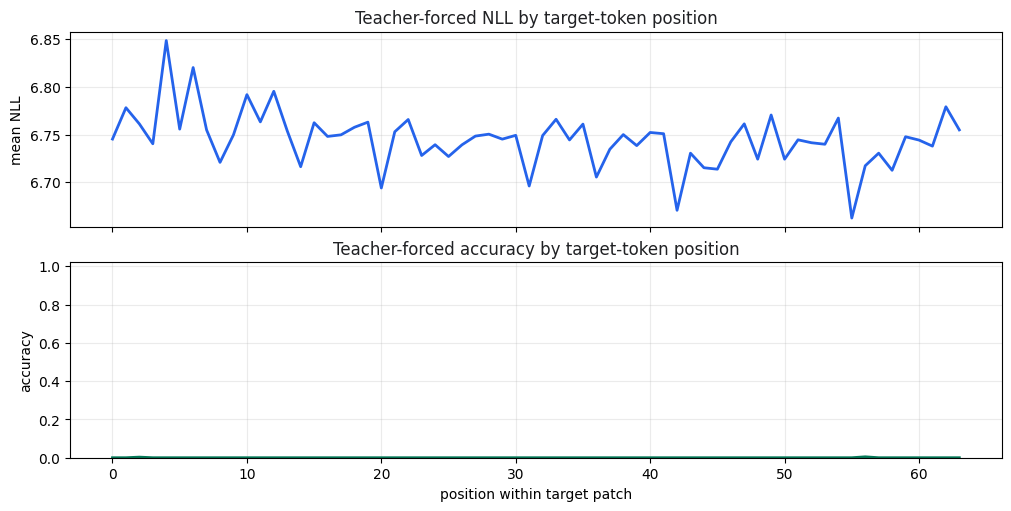

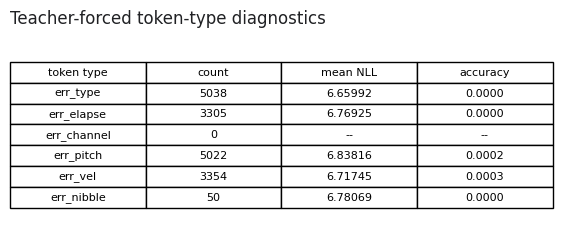

In [17]:
# Per-position teacher-forced diagnostics from the existing forward pass.
logits = insp['logits'].detach()
target = insp['target_patches'].detach()
labels = torch.cat((torch.full((target.shape[0], 1), d.bos_token_id, dtype=target.dtype), target), dim=1)
labels = labels.masked_fill(labels == d.special_token_id, -100)
shift_logits = logits[:, :-1]
shift_labels = labels[:, 1:]
valid = shift_labels != -100
nll = F.cross_entropy(shift_logits.reshape(-1, shift_logits.shape[-1]),
                     shift_labels.clamp_min(0).reshape(-1), reduction='none').reshape_as(shift_labels)
nll = nll.masked_fill(~valid, float('nan'))
correct = (shift_logits.argmax(-1) == shift_labels) & valid
pos_count = valid.sum(0).tolist()
pos_loss = torch.nanmean(nll, dim=0).cpu()
pos_acc = (correct.float().masked_fill(~valid, float('nan'))).nanmean(0).cpu()

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, layout='constrained')
axes[0].plot(pos_loss.numpy(), color=ACCENT, linewidth=2)
axes[0].set_title('Teacher-forced NLL by target-token position', color=INK)
axes[0].set_ylabel('mean NLL'); axes[0].grid(alpha=.25)
axes[1].plot(pos_acc.numpy(), color=CORRECTED, linewidth=2)
axes[1].set_title('Teacher-forced accuracy by target-token position', color=INK)
axes[1].set_xlabel('position within target patch'); axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.02); axes[1].grid(alpha=.25)
plt.show()

# Group by the target token type used by the existing metric implementation.
type_ids = model.type_of_id[shift_labels.clamp_min(0)].detach().cpu()
group_rows = []
for code, name in sorted(model.type_names.items()):
    sel = valid.cpu() & (type_ids == code)
    count = int(sel.sum())
    group_rows.append([name, count,
                       '--' if count == 0 else f'{float(nll.cpu()[sel].mean()):.5f}',
                       '--' if count == 0 else f'{float(correct.cpu()[sel].float().mean()):.4f}'])
fig, ax = plt.subplots(figsize=(7, 2.6))
metric_table(ax, ['token type', 'count', 'mean NLL', 'accuracy'], group_rows,
             'Teacher-forced token-type diagnostics')
plt.show()
assert int(valid.sum()) > 0 and torch.isfinite(nll[valid]).all()

## 7. Overfit one batch — loss should drop, acc should rise

In [18]:
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(20):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['acc']))
    if step % 5 == 0 or step == 19:
        print(f'step {step:02d}  loss={loss.item():.4f}  acc={metric["acc"]:.4f}')

# grads flow to the raw-lyl prefix embedding (the only path lilylet influences the loss).
g = model.deducer.lyl_prefix_embedding.weight.grad
print('\nlyl_prefix_embedding grad finite:', g is not None and bool(torch.isfinite(g).all()))
print('loss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('acc  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease'

step 00  loss=6.7467  acc=0.0001
step 05  loss=5.6299  acc=0.4635
step 10  loss=4.8628  acc=0.5484
step 15  loss=4.2227  acc=0.5883
step 19  loss=3.7724  acc=0.6030

lyl_prefix_embedding grad finite: True
loss start -> end: 6.7467 -> 3.7724
acc  start -> end: 0.0001 -> 0.603


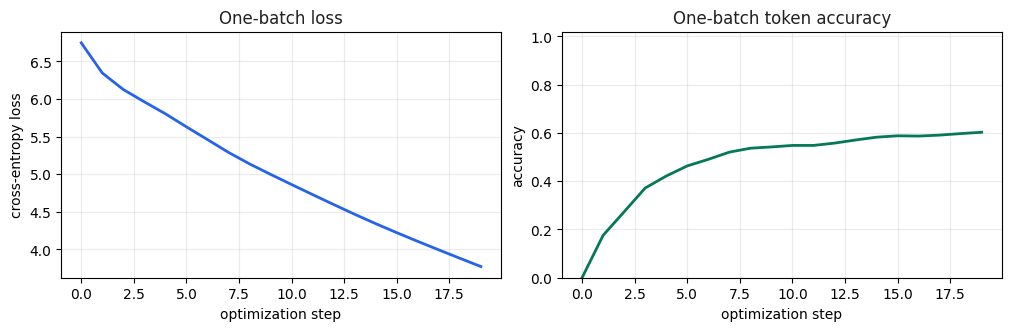

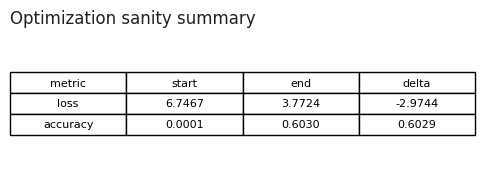

In [19]:
# Separate scales: the overfit sanity check is not a generalization metric.
losses = [h[0] for h in history]
accs = [h[1] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), layout='constrained')
axes[0].plot(losses, color=ACCENT, linewidth=2)
axes[0].set_title('One-batch loss', color=INK)
axes[0].set_xlabel('optimization step'); axes[0].set_ylabel('cross-entropy loss')
axes[0].grid(alpha=.25)
axes[1].plot(accs, color=CORRECTED, linewidth=2)
axes[1].set_title('One-batch token accuracy', color=INK)
axes[1].set_xlabel('optimization step'); axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.02); axes[1].grid(alpha=.25)
plt.show()

fig, ax = plt.subplots(figsize=(6, 1.8))
metric_table(ax, ['metric', 'start', 'end', 'delta'], [
    ['loss', f'{losses[0]:.4f}', f'{losses[-1]:.4f}', f'{losses[-1] - losses[0]:.4f}'],
    ['accuracy', f'{accs[0]:.4f}', f'{accs[-1]:.4f}', f'{accs[-1] - accs[0]:.4f}'],
], 'Optimization sanity summary')
plt.show()

## 8. Generated patch termination — fixed width versus emitted length

Every stored MIDI patch is width 64. Early `<eom>` or `<pad>` termination is represented by right-padding the remainder; therefore storage width and emitted length are different quantities. This diagnostic reads an existing generated output when available and flags the failure signature: no terminator and every patch consuming all 64 token slots.

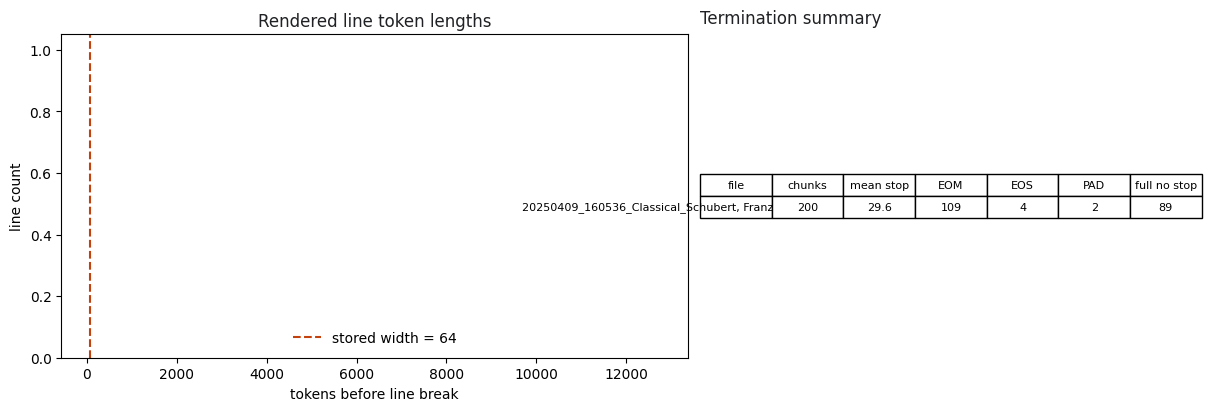

A full-width patch with no EOM/PAD is a generation failure signature, not a padding bug.


In [20]:
import glob

PAD_ID, EOS_ID, EOM_ID = 0, 2, 4
output_candidates = glob.glob(str(REPO_ROOT / 'tests' / 'output' / 'midiseq2_prefixtl_from_lilylet' / '*.midiseq2.txt'))
termination_rows = []
for output_path in output_candidates[:5]:
    token_lines = [line.split() for line in Path(output_path).read_text(encoding='utf-8').splitlines() if line.strip()]
    # The renderer writes one measure per line; split each line into patch-width chunks for this diagnostic.
    flat = [tok for line in token_lines for tok in line]
    ids = []
    for tok in flat:
        try:
            ids.append(int(tok))
        except ValueError:
            # Generated text is symbolic; use the known special-token spellings and retain other tokens.
            ids.append({'<pad>': PAD_ID, '<eos>': EOS_ID, '<eom>': EOM_ID}.get(tok, -1))
    patches = [ids[i:i + d.patch_size] for i in range(0, len(ids), d.patch_size)]
    lengths = []
    eom_count = eos_count = pad_stop_count = full_no_stop = 0
    for patch in patches:
        if len(patch) < d.patch_size:
            patch += [PAD_ID] * (d.patch_size - len(patch))
        pad_at = next((i for i, x in enumerate(patch) if x == PAD_ID), None)
        eom_at = next((i for i, x in enumerate(patch) if x == EOM_ID), None)
        eos_at = next((i for i, x in enumerate(patch) if x == EOS_ID), None)
        stop_at = min([x for x in (pad_at, eom_at) if x is not None], default=d.patch_size)
        lengths.append(stop_at)
        eom_count += eom_at is not None
        eos_count += eos_at is not None
        pad_stop_count += pad_at is not None
        full_no_stop += stop_at == d.patch_size
    termination_rows.append([Path(output_path).name, len(patches),
                             f'{sum(lengths) / max(1, len(lengths)):.1f}',
                             eom_count, eos_count, pad_stop_count, full_no_stop])

if termination_rows:
    fig = plt.figure(figsize=(12, 4), layout='constrained')
    gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1])
    sample_path = output_candidates[0]
    flat_lines = [line.split() for line in Path(sample_path).read_text(encoding='utf-8').splitlines() if line.strip()]
    lengths = []
    for line in flat_lines:
        # A rendered line is a measure; use its token count as a visible emitted-length diagnostic.
        lengths.append(len(line))
    axes = fig.add_subplot(gs[0, 0])
    axes.hist(lengths, bins=min(20, max(1, len(set(lengths)))), color=ACCENT, edgecolor='white')
    axes.axvline(d.patch_size, color=HISTORICAL, linestyle='--', label='stored width = 64')
    axes.set_title('Rendered line token lengths', color=INK)
    axes.set_xlabel('tokens before line break'); axes.set_ylabel('line count'); axes.legend(frameon=False)
    metric_table(fig.add_subplot(gs[0, 1]),
                 ['file', 'chunks', 'mean stop', 'EOM', 'EOS', 'PAD', 'full no stop'],
                 termination_rows, 'Termination summary')
    plt.show()
    print('A full-width patch with no EOM/PAD is a generation failure signature, not a padding bug.')
else:
    print('No generated midiseq2 output found; termination visualization skipped.')